# 篇末综合 系统边界与实验设计

## 学习目标与先修知识

- 为观测（observation）变化区分跨边界移动与内部生成。
- 在明确假设下计算并核对收支（mass balance）。
- 比较独立实验的事前预测，限定模型（model）的解释范围。

**先修知识**：第 1 篇四章；复习[设计可以区分解释的实验](../04-模型假设与计算实验/02-设计可以区分解释的实验.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

三个场景检验同一套习惯：显微视野中的细胞计数、带散热旁路的温度调节、两种清除规则的比较。它们不需要一个统一的大模型，而需要统一的提问方式：边界在哪里，量是什么，规则是什么，怎样核对？

先看计数：视野起点 10 个细胞，第一段进入 2、离开 1、分裂净新增 1；第二段进入 0、离开 3、分裂净新增 2。净数量下降能否说明没有分裂？

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
initial = 10
entered,left,born = [2,0],[1,3],[1,2]
display(Markdown(show_table(['段','进入 / 个','离开 / 个','分裂净新增 / 个'],zip([1,2],entered,left,born))))

| 段 | 进入 / 个 | 离开 / 个 | 分裂净新增 / 个 |
| --- | --- | --- | --- |
| 1 | 2 | 1 | 1 |
| 2 | 0 | 3 | 2 |

## 模型假设

系统边界（system boundary）是显微视野，不是整个培养孔。各段计数已经累计；忽略死亡和计数误差。一次一变二的分裂净增加 1 个细胞，不能记成新增 2 个。

温度场景采用以下关系：偏差增加使散热增强，散热减小偏差并增加失水。清除场景比较每段固定移除 1 U 或比例移除 10% 两个候选，比较前固定这两组参数（parameter）。

## 数学解释与推导

细胞账目为：末数量 = 初数量 + 进入 − 离开 + 内部净新增。因此第一段为 12，第二段为 11。细胞数不是所追踪物质总量（tracked amount）；分裂净新增必须单独记账。

对多个清除实验，每次都从独立的起点 A₀ 开始，固定量终点为 A₀−nc，比例终点为 A₀(1−r)ⁿ。比较时必须保留 n、c、r 不变，不能把前一个实验末值当成下一个实验起点。

反馈（feedback）图检查的是作用路径，计数检查的是账目，候选比较检查的是假设预测。三者提供的证据不同，不互相替代。

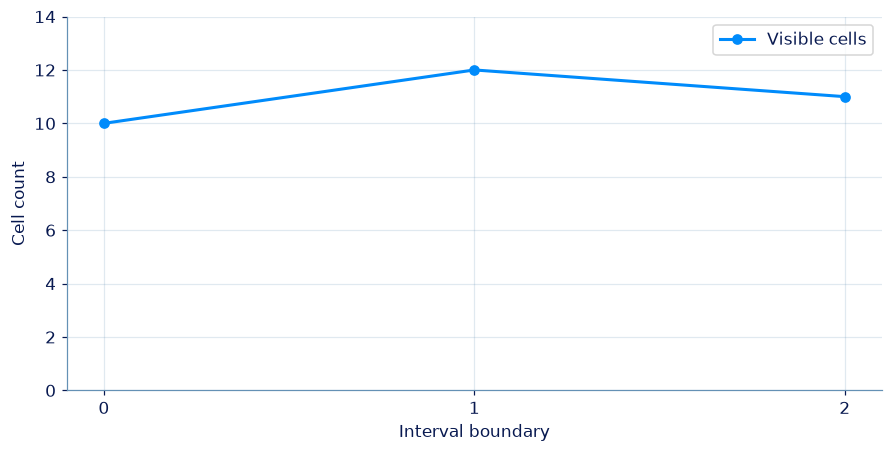

In [2]:
def count_cells(initial, entered, left, born):
    counts=[initial]
    for u,v,b in zip(entered,left,born):
        counts.append(counts[-1]+u-v+b)
    return counts

counts=count_cells(initial,entered,left,born)
assert counts == [10,12,11]
assert counts[-1]-initial == sum(entered)-sum(left)+sum(born)
fig, ax = plt.subplots()
ax.plot(range(3),counts,'o-',label='Visible cells')
ax.set(xlabel='Interval boundary',ylabel='Cell count',xticks=range(3),ylim=(0,14))
ax.legend()
plt.show()

## 对照实验

按相同的两段观察长度，独立从 10 与 20 U 开始清除实验。写下两套终点预测，比较它们怎样随起点变化；再检查空实验和零段数的结果。

In [3]:
initials=[10,20]
fixed_ends=[a-2*1 for a in initials]
fraction_ends=[a*(1-.1)**2 for a in initials]
display(Markdown(show_table(['起点 / U','固定量两段末 / U','比例两段末 / U'],zip(initials,fixed_ends,fraction_ends))))
assert fixed_ends == [8,18]
assert all(abs(x-y)<1e-12 for x,y in zip(fraction_ends,[8.1,16.2]))
assert count_cells(0,[],[],[]) == [0]

| 起点 / U | 固定量两段末 / U | 比例两段末 / U |
| --- | --- | --- |
| 10 | 8 | 8.1 |
| 20 | 18 | 16.2 |

## 结果解释

细胞数从 12 降到 11 时仍发生了净新增 2；净变化把多个过程相加，不能直接等同某一种机制。扩大到培养孔边界会改变迁移分类，也需要重新定义观测。

从边界和变量出发，我们把细胞计数写成账目，把温度调节连成反馈，再用不同起点区分两种清除规则。下一篇将进一步研究：把时间段缩短后，怎样描述持续发生的变化？

[本章导览与各节入口](http://127.0.0.1:8000/parts/01-看见系统/综合练习/)

## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 多项选择题：细胞计数的边界

篇末场景：每小时拍摄培养孔中央视野。细胞可以进入或离开视野，也可能分裂。把“可见细胞数”作为存量（stock）时，哪些判断正确？

- **A.** 边界是视野，跨边界移动会改变可见数量。
- **B.** 可见数量增加足以证明所有增加都来自分裂。
- **C.** 需要分别考虑跨边界迁入迁出与视野内部的生成。
- **D.** 若改成整个培养孔，内部跨视野移动不再是孔的外部流量（flow）。

[作答：细胞计数的边界](http://127.0.0.1:8000/parts/01-%E7%9C%8B%E8%A7%81%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p01-cap-boundary)

### 第 2 题 · 基础辨析 · 10 分 · 单项选择题：先分清累计数量与变化速率

同一细胞视野在 2 小时内累计进入 6 个、离开 2 个，内部净新增 3 个。初始可见数量为 10 个。哪项记账正确？

- **A.** 末数量为 10+2×(6−2+3)=24 个。
- **B.** 末数量为 10+6−2+3=17 个。
- **C.** 只要数量增加，就可把增加量全部记为迁入。
- **D.** 进入数 6 个与进入速率 6 个/小时可直接互换。

[作答：先分清累计数量与变化速率](http://127.0.0.1:8000/parts/01-%E7%9C%8B%E8%A7%81%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p01-cap-units)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：计数中的移动与新增

给定视野起始细胞数，每段已累计的进入、离开和分裂净新增数。一次一变二的分裂只净增加一个细胞。分别计入这三项，返回可见数量轨迹（trajectory）。

**函数与代码模板**

```python
def solve(
    initial: int,
    entered: list[int],
    left: list[int],
    born: list[int],
) -> list[int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `int` | 起始可见细胞数。 | 个 |
| `entered` | `list[int]` | 各段跨边界进入数。 | 个 |
| `left` | `list[int]` | 各段跨边界离开数。 | 个 |
| `born` | `list[int]` | 各段分裂净新增数。 | 个 |

**返回值**

直接返回 counts（list[int]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `counts` | `list[int]` | 起点与各段末的可见细胞数。 | 个 |

**计算规则**

新数量 = 旧数量 + entered[i] − left[i] + born[i]。各段这些数已累计，不再乘时长；题设忽略死亡。

**约束与边界**

- 所有数值均为有限数。
- 三个列表等长，长度 0 到 1000；所有计数都是 0 到 10000 的整数。
- 各段末数量保证非负。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 起始可见细胞数。 | 10 | 个 |
| entered | 各段跨边界进入数。 | [2, 0] | 个 |
| left | 各段跨边界离开数。 | [1, 3] | 个 |
| born | 各段分裂净新增数。 | [1, 2] | 个 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = 10
entered = [2, 0]
left = [1, 3]
born = [1, 2]

result = solve(initial, entered, left, born)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| counts | 起点与各段末的可见细胞数。 | [10, 12, 11] | 个 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [10, 12, 11]
```

**样例解释**

第一段 10+2−1+1=12；第二段 12+0−3+2=11。第二段数量下降，但仍有分裂新增，下降不能证明“没有分裂”。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计数中的移动与新增](http://127.0.0.1:8000/parts/01-%E7%9C%8B%E8%A7%81%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p01-cap-count)

### 第 4 题 · 方法应用 · 15 分 · 多项选择题：偏差下降与旁路影响

篇末人工调节模型（model）：温度偏差增大会增强散热，散热会降低温度偏差并增加失水。哪些结论合理？

- **A.** 温度调节方向属于负反馈（negative feedback）。
- **B.** 温度偏差下降说明其他变量必然也改善。
- **C.** 若存在延迟（delay），需要看同步轨迹（trajectory），不能只看起点和终点。
- **D.** 这些作用方向是具体假设，应分别用观测（observation）核对。

[作答：偏差下降与旁路影响](http://127.0.0.1:8000/parts/01-%E7%9C%8B%E8%A7%81%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p01-cap-feedback)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：在多种初值下保留两套预测

篇末清除实验：每段固定移除 fixed，或移除当前量的 fraction。在每个候选初值（initial condition）下都执行相同的 steps 段，只返回两组终点预测，以便与后续观测（observation）比较。

**函数与代码模板**

```python
def solve(
    initials: list[float],
    fixed: float,
    fraction: float,
    steps: int,
) -> tuple[list[float], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initials` | `list[float]` | 各独立实验的起点所追踪物质总量（tracked amount）。 | U |
| `fixed` | `float` | 固定规则每段移除量。 | U/段 |
| `fraction` | `float` | 比例规则每段移除比例。 | 无量纲 |
| `steps` | `int` | 每个独立实验的段数。 | 段 |

**返回值**

按以下顺序返回元组：(fixed_ends, fraction_ends)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `fixed_ends` | `list[float]` | 依照初值顺序排列的固定量规则终点。 | U |
| `fraction_ends` | `list[float]` | 依照初值顺序排列的比例规则终点。 | U |

**计算规则**

各实验独立重置到该初值。固定规则重复相减，比例规则重复乘 (1−fraction)。不得把上一实验终点作为下一实验起点。

**约束与边界**

- 所有数值均为有限数。
- 0 ≤ len(initials) ≤ 100；0 ≤ steps ≤ 100；0 ≤ fraction ≤ 1。
- 0 ≤ fixed ≤ A ≤ 1000，且 fixed×steps ≤ 每个 A。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initials | 各独立实验的起点所追踪物质总量（tracked amount）。 | [10, 20] | U |
| fixed | 固定规则每段移除量。 | 1 | U/段 |
| fraction | 比例规则每段移除比例。 | 0.1 | 无量纲 |
| steps | 每个独立实验的段数。 | 2 | 段 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initials = [10, 20]
fixed = 1
fraction = 0.1
steps = 2

result = solve(initials, fixed, fraction, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| fixed_ends | 依照初值顺序排列的固定量规则终点。 | [8, 18] | U |
| fraction_ends | 依照初值顺序排列的比例规则终点。 | [8.1, 16.2] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([8, 18], [8.1, 16.2])
```

**样例解释**

从 10 和 20 分别独立出发，固定组各减 2；比例组各乘 0.9 两次。两次实验不能首尾接在一起。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：在多种初值下保留两套预测](http://127.0.0.1:8000/parts/01-%E7%9C%8B%E8%A7%81%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p01-cap-predictions)

### 第 6 题 · 综合验证 · 15 分 · 多项选择题：用新初值区分候选规则

两个清除模型（model）在起点 10 U 时都预测一段后为 9 U：甲每段减 1 U，乙每段减当前量的 10%。另做一次独立实验，起点 20 U，一段后测得 18.1 U，事先规定预测与读数的差不超过 0.2 U 才相符。哪些判断成立？

- **A.** 甲预测 19 U，乙预测 18 U，新条件能区分这两项预测。
- **B.** 甲与观测（observation）相符，因为它在原实验中通过了检查。
- **C.** 本次读数与乙相符，但这不证明乙适用于所有初值（initial condition）和所有时段。
- **D.** 应先固定允许误差与实验时长，再看观测结果。

[作答：用新初值区分候选规则](http://127.0.0.1:8000/parts/01-%E7%9C%8B%E8%A7%81%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p01-cap-discriminate)

### 第 7 题 · 迁移挑战 · 10 分 · Python 计算题：换测量方式后核对收支

仪器满足读数 = gain×可见数量 + offset。先换算各时刻数量，再核对已记录的移动和内部新增，返回各段尚未被这些记录解释的净流出量。正数表示额外净减少，负数表示额外净增加；残差（residual）本身不能识别死亡、漏记或其他原因。

**函数与代码模板**

```python
def solve(
    readings: list[float],
    gain: float,
    offset: float,
    entered: list[float],
    left: list[float],
    born: list[float],
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `readings` | `list[float]` | 各段边界的仪器读数，含起点。 | 读数单位 |
| `gain` | `float` | 每个细胞对应的读数增量，严格为正。 | 读数单位/个 |
| `offset` | `float` | 固定零点偏移。 | 读数单位 |
| `entered` | `list[float]` | 各段已累计的进入数。 | 个 |
| `left` | `list[float]` | 各段已累计的离开数。 | 个 |
| `born` | `list[float]` | 各段已累计的净新增数。 | 个 |

**返回值**

直接返回 unexplained（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `unexplained` | `list[float]` | 按时间顺序的未解释净流出量。 | 个 |

**计算规则**

令 N[i]=(readings[i]−offset)/gain。返回 N[i]+entered[i]−left[i]+born[i]−N[i+1]；保留正负号，不取绝对值、不裁剪。

**约束与边界**

- 所有数值均为有限数；无需修改输入（input）。
- 0—100 段；readings 比其余三个等长列表多一项。
- 0.01≤gain≤100，|offset|≤1000；换算数量与各段记录数在 0—10000 内。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| readings | 各段边界的仪器读数，含起点。 | [21, 25, 23] | 读数单位 |
| gain | 每个细胞对应的读数增量，严格为正。 | 2 | 读数单位/个 |
| offset | 固定零点偏移。 | 1 | 读数单位 |
| entered | 各段已累计的进入数。 | [3, 0] | 个 |
| left | 各段已累计的离开数。 | [0, 2] | 个 |
| born | 各段已累计的净新增数。 | [0, 2] | 个 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
readings = [21, 25, 23]
gain = 2
offset = 1
entered = [3, 0]
left = [0, 2]
born = [0, 2]

result = solve(readings, gain, offset, entered, left, born)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| unexplained | 按时间顺序的未解释净流出量。 | [1, 1] | 个 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1, 1]
```

**样例解释**

读数换算为 10、12、11 个。第一段记录预测为 13，实际为 12，未解释净流出 1；第二段 12−2+2−11=1。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：换测量方式后核对收支](http://127.0.0.1:8000/parts/01-%E7%9C%8B%E8%A7%81%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p01-cap-calibrated-balance)

### 第 8 题 · 迁移挑战 · 10 分 · 多项选择题：换观察边界后限定结论

在新培养孔中，中央视野可见数量由 20 降为 15 个，全孔数量保持 100 个。视野与全孔的仪器都已换算成细胞数；没有逐个追踪迁移、分裂和死亡。哪些结论有依据？

- **A.** 全孔总数不变，可以推出没有发生分裂或死亡。
- **B.** 中央视野的净减少与向外迁移相容，但也可能由多种过程共同造成。
- **C.** 改用全孔边界时，孔内跨视野移动不再计为全孔外部流量（flow）。
- **D.** 只凭这两组计数，仍不能唯一识别各项内部生成与损失。

[作答：换观察边界后限定结论](http://127.0.0.1:8000/parts/01-%E7%9C%8B%E8%A7%81%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p01-cap-limits)

**进一步阅读**

[MIT 15.871 Assignment 3](https://ocw.mit.edu/courses/15-871-introduction-to-system-dynamics-fall-2013/b950bd7b4f565b7b19145fb16bd55c8e_MIT15_871F13_ass3.pdf)：A—B 部分辨认量、边界及物质连接，C 部分讨论积累，D 部分讨论目标调节。本节数值和代码是独立设计的教学例子。